# Lesson 1: Introduction to Pandas

Pandas is the most commonly used library for data analysis in python.
It contains data structures and data manipulation tools designed to make data cleaning and analysis fast and easy in Python. It is often used in tandem with numerical computing tools like NumPy and SciPy, analytical libraries like statsmodels and scikit-learn, and data visualization libraries like matplotlib.


Useful references:

- https://pandas.pydata.org/docs/user_guide/index.html#user-guide

- https://jakevdp.github.io/PythonDataScienceHandbook/

- https://www.programmer-books.com/wp-content/uploads/2019/04/Python-for-Data-Analysis-2nd-Edition.pdf



All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University, unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---

As we saw, NumPy’s ndarray data structure provides essential features for the type of clean, well-organized data typically seen in numerical computing tasks. While it serves this purpose very well, its limitations become clear when we need more flexi‐ bility (attaching labels to data, working with missing data, etc.) and when attempting operations that do not map well to element-wise broadcasting (groupings, pivots, etc.), each of which is an important piece of analyzing the less structured data avail‐ able in many forms in the world around us. Pandas, and in particular its Series and DataFrame objects, builds on the NumPy array structure and provides efficient access to these sorts of “data munging” tasks that occupy much of a data scientist’s time.

Generally speaking, when we have to work on Tabular data, we prefer the pandas module. Otherwise, for numerical data, we will use the numpy module.

To get started with pandas, you will need to get comfortable with its two workhorse data structures: Series and DataFrame.


In this module, we will cover

- 1: Data Structure
- 2: Data Indexing and Selection
- 3: The Pandas Index Object
- 4: Sorting and Ranking
- 5: Arithmetic and Data Alignment
- 6: Combining Datasets
- 7: US data
- 8: Operations between DataFrame and Series
- 9: Function Application and Mapping
- 10: Summarizing and Computing Descriptive Statistics
- 11: Simple Plotting with Pandas
- 12: Task



Import the modules needed for this notebook:

In [1]:
import numpy as np
import pandas as pd

---
## 1: Data Structure



### Series

The most basic Data Structure available in Pandas is the Series.

A `Series` is a one-dimensional array-like object containing a sequence of values (of similar types to NumPy types) and an associated array of data labels, called its index. The simplest Series is formed from only an array of data.

In [2]:
data = pd.Series([1, 8, -5, 3])
data

0    1
1    8
2   -5
3    3
dtype: int64

The string representation of a Series displayed interactively shows the index on the left and the values on the right. Since we did not specify an index for the data, a default one consisting of the integers 0 through N - 1 (where N is the length of the data) is created.

In [3]:
data.values

array([ 1,  8, -5,  3])

In [4]:
data.index

RangeIndex(start=0, stop=4, step=1)

In [5]:
data[2]

-5

In [6]:
data[1:3]

1    8
2   -5
dtype: int64

Often it will be desirable to create a Series with an index identifying each data point with a label:

In [7]:
data = pd.Series([9, 7, -1, 3], index=['e', 'a', 'r', 'l'])
data

e    9
a    7
r   -1
l    3
dtype: int64

In [8]:
data.index

Index(['e', 'a', 'r', 'l'], dtype='object')

Compared with NumPy arrays, you can use labels in the index when selecting single values or a set of values:

In [9]:
data['e']

9

In [10]:
data[['a', 'e', 'r']]

a    7
e    9
r   -1
dtype: int64

In [11]:
data[data > 0]

e    9
a    7
l    3
dtype: int64

In [12]:
data * 2

e    18
a    14
r    -2
l     6
dtype: int64

In [13]:
# do math

np.exp(data)

e    8103.083928
a    1096.633158
r       0.367879
l      20.085537
dtype: float64

Another way to think about a Pandas Series is as a fixed-length, ordered Python dict, as it is a mapping of index values to data values. It can be used in many contexts where you might use a dict:

In [14]:
'b' in data

False

In [15]:
'e' in data

True

Should you have data contained in a Python dict, you can create a Series from it by passing the dict.
The dict.key will become the index, and the dict.value will become the values of the series.

In [16]:
my_data = {'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}

In [17]:
population = pd.Series(my_data)

In [18]:
population

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

When you are only passing a dict, the index in the resulting Series will have the dict’s keys in sorted order. You can override this by passing the dict keys in the order you want them to appear in the resulting Series:

In [19]:
states = ['California', 'Ohio', 'Oregon', 'Texas']

In [20]:
population1 = pd.Series(my_data, index=states)

In [21]:
population1

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

Here, three values found in sdata were placed in the appropriate locations, but since no value for 'California' was found, it appears as NaN (not a number), which is considered in pandas to mark missing or NA values. Since 'Utah' was not included in states, it is excluded from the resulting object.

In [22]:
pd.isnull(population1)

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [23]:
pd.notnull(population1)

California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

Series also has these as instance methods:

In [24]:
population1.isnull()

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [25]:
population + population1

California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

In [26]:
population1.name = 'population'

In [27]:
population1.index.name = 'state'

In [28]:
population1

state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64

In [29]:
# A Series’s index can be altered in-place by assignment:

data = pd.Series([0, 4, 2, -5])
data

0    0
1    4
2    2
3   -5
dtype: int64

In [30]:
data.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
data

Bob      0
Steve    4
Jeff     2
Ryan    -5
dtype: int64

In [31]:
data['Steve']=9
data

Bob      0
Steve    9
Jeff     2
Ryan    -5
dtype: int64

---
### DataFrame

A `DataFrame` represents a rectangular table of data and contains an ordered collection of columns, each of which can be a different value type (numeric, string, boolean, etc.). The `DataFrame` has both a row and column index; it can be thought of as a dict of Series all sharing the same index. Under the hood, the data is stored as one or more two-dimensional blocks rather than a list, dict, or some other collection of one-dimensional arrays.

If the nested dict is passed to the DataFrame, pandas will interpret the outer dict keys as the columns and the inner keys as the row indices:

In [32]:
data = {'state': ['California', 'Vermont', 'Arizona', 'Ohio', 'Nevada', 'Kansas'],
            'year': [2003, 2003, 2002, 2001, 2002, 2003],
            'pop': [15, 1.7, 3.6, 2.4, 2.9, 3.2]}

df = pd.DataFrame(data) # pandas dataframe
df

,state,year,pop
0,California,2003,15.0
1,Vermont,2003,1.7
2,Arizona,2002,3.6
3,Ohio,2001,2.4
4,Nevada,2002,2.9
5,Kansas,2003,3.2


In [33]:
df.index

RangeIndex(start=0, stop=6, step=1)

In [34]:
df.columns

Index(['state', 'year', 'pop'], dtype='object')

In [35]:
# For large DataFrames, the head method selects only the first five rows:
df.head()

,state,year,pop
0,California,2003,15.0
1,Vermont,2003,1.7
2,Arizona,2002,3.6
3,Ohio,2001,2.4
4,Nevada,2002,2.9


In [36]:
# column can be specified

pd.DataFrame(data, columns=['year', 'state', 'pop'])

,year,state,pop
0,2003,California,15.0
1,2003,Vermont,1.7
2,2002,Arizona,3.6
3,2001,Ohio,2.4
4,2002,Nevada,2.9
5,2003,Kansas,3.2


In [37]:
# Even if some keys in the dictionary are missing, Pandas will fill them in with NaN (i.e., “not a number”) values

df2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
                     index=['one', 'two', 'three', 'four',
                            'five', 'six'])
df2

,year,state,pop,debt
one,2003,California,15.0,NaN
two,2003,Vermont,1.7,NaN
three,2002,Arizona,3.6,NaN
four,2001,Ohio,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Kansas,3.2,NaN


A column in a DataFrame can be retrieved as a Series:

In [38]:
df2['state']

one      California
two         Vermont
three       Arizona
four           Ohio
five         Nevada
six          Kansas
Name: state, dtype: object

In [39]:
# another way of calling a column:
df2.state

one      California
two         Vermont
three       Arizona
four           Ohio
five         Nevada
six          Kansas
Name: state, dtype: object

Rows can also be retrieved by position or name with the special `loc` attribute

In [40]:
df2.loc['three']

year        2002
state    Arizona
pop          3.6
debt         NaN
Name: three, dtype: object

Columns can be modified by assignment. For example, the empty 'debt' column could be assigned a scalar value or an array of values:

In [41]:
df2['debt'] = 16.5
df2

,year,state,pop,debt
one,2003,California,15.0,16.5
two,2003,Vermont,1.7,16.5
three,2002,Arizona,3.6,16.5
four,2001,Ohio,2.4,16.5
five,2002,Nevada,2.9,16.5
six,2003,Kansas,3.2,16.5


In [42]:
df2['debt'] = np.arange(6.)
df2

,year,state,pop,debt
one,2003,California,15.0,0.0
two,2003,Vermont,1.7,1.0
three,2002,Arizona,3.6,2.0
four,2001,Ohio,2.4,3.0
five,2002,Nevada,2.9,4.0
six,2003,Kansas,3.2,5.0


When you are assigning lists or arrays to a column, the value’s length must match the length of the DataFrame. If you assign a Series, its labels will be realigned exactly to the DataFrame’s index, inserting missing values in any holes:

In [43]:
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
val

two    -1.2
four   -1.5
five   -1.7
dtype: float64

In [44]:
df2['debt'] = val
df2

,year,state,pop,debt
one,2003,California,15.0,NaN
two,2003,Vermont,1.7,-1.2
three,2002,Arizona,3.6,NaN
four,2001,Ohio,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Kansas,3.2,NaN


Assigning a column that doesn’t exist will create a new column. The del keyword will delete columns as with a dict.

In [45]:
df2['eastern'] = df2.state == 'Arizona'

In [46]:
df2

,year,state,pop,debt,eastern
one,2003,California,15.0,NaN,False
two,2003,Vermont,1.7,-1.2,False
three,2002,Arizona,3.6,NaN,True
four,2001,Ohio,2.4,-1.5,False
five,2002,Nevada,2.9,-1.7,False
six,2003,Kansas,3.2,NaN,False


The del method can then be used to remove this column:

In [47]:
del df2['eastern']

In [48]:
df2.columns

Index(['year', 'state', 'pop', 'debt'], dtype='object')

Another common form of data is a nested dict of dicts:

In [49]:
pop = {'Nevada': {2001: 2.4, 2002: 2.9},
        'Ohio': {2000: 1.5, 2001: 1.7, 2002: 3.6}}
df3 = pd.DataFrame(pop)
df3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


You can transpose the DataFrame (swap rows and columns) with similar syntax to a NumPy array:

In [50]:
df3.T

,2001,2002,2000
Nevada,2.4,2.9,NaN
Ohio,1.7,3.6,1.5


The keys in the inner dicts are combined and sorted to form the index in the result. This isn’t true if an explicit index is specified:

In [51]:
pd.DataFrame(pop, index=[2001, 2002, 2003])

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2003,NaN,NaN


Dicts of Series are treated in much the same way:

In [52]:
pdata = {'Ohio': df3['Ohio'][:-1],
          'Nevada': df3['Nevada'][:2]}
pd.DataFrame(pdata)

,Ohio,Nevada
2001,1.7,2.4
2002,3.6,2.9


In [53]:
df3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


If a DataFrame’s index and columns have their name attributes set, these will also be
displayed:

In [54]:
df3.index.name = 'year'
df3.columns.name = 'state'

As with Series, the values attribute returns the data contained in the DataFrame as a two-dimensional ndarray:

In [55]:
df3

state,Nevada,Ohio
year,,
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [56]:
df3.columns.name = 'US_state'
df3

US_state,Nevada,Ohio
year,,
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [57]:
df3.values

array([[2.4, 1.7],
       [2.9, 3.6],
       [nan, 1.5]])

If the DataFrame’s columns are different dtypes, the dtype of the values array will be chosen to accommodate all of the columns:

In [58]:
df2.values

array([[2003, 'California', 15.0, nan],
       [2003, 'Vermont', 1.7, -1.2],
       [2002, 'Arizona', 3.6, nan],
       [2001, 'Ohio', 2.4, -1.5],
       [2002, 'Nevada', 2.9, -1.7],
       [2003, 'Kansas', 3.2, nan]], dtype=object)

Selections with duplicate labels will select all occurrences of that label.


---
## 2: Data Indexing and Selection

We’ll look at means of accessing and modifying values in Pandas Series and DataFrame objects.


https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

---
### Data Selection in Series

`Series` indexing (obj[...]) works analogously to NumPy array indexing, except you can use the Series’s index values instead of only integers. Here are some examples of this:


In [59]:
obj = pd.Series(np.arange(4.), index=['a', 'b', 'c', 'd'])
obj

a    0.0
b    1.0
c    2.0
d    3.0
dtype: float64

In [60]:
obj['b']

1.0

In [61]:
obj[1]

1.0

In [62]:
obj[2:4]

c    2.0
d    3.0
dtype: float64

In [63]:
obj[['b', 'a', 'd']]

b    1.0
a    0.0
d    3.0
dtype: float64

In [64]:
obj[obj < 2] # boolean

a    0.0
b    1.0
dtype: float64

Slicing with labels behaves differently than normal Python slicing in that the end‐point is inclusive:

In [65]:
obj['b':'d']

b    1.0
c    2.0
d    3.0
dtype: float64

Setting using these methods modifies the corresponding section of the Series:

In [66]:
obj['b':'c'] = 5

In [67]:
obj

a    0.0
b    5.0
c    5.0
d    3.0
dtype: float64

---
### Data Selection in DataFrame


Indexing into a DataFrame is for retrieving one or more columns either with a single value or sequence:

In [68]:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                     index=['Ohio', 'Colorado', 'Utah', 'New York'],
                     columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [69]:
data['two'] # call 1 column

Ohio         1
Colorado     5
Utah         9
New York    13
Name: two, dtype: int64

In [70]:
data[['three', 'one']] # 2 columns

,three,one
Ohio,2,0
Colorado,6,4
Utah,10,8
New York,14,12


Indexing like this has a few special cases. First, slicing or selecting data with a boolean array:

In [71]:
data < 5

,one,two,three,four
Ohio,True,True,True,True
Colorado,True,False,False,False
Utah,False,False,False,False
New York,False,False,False,False


In [72]:
data[data['three'] > 5] # selection by boolean condition

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


The row selection syntax data[:2] is provided as a convenience. Passing a single element or a list to the [] operator selects columns.

In [73]:
data[:2] # rows 0 and 1

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7


---
### iloc and loc

loc is primarily label based, but may also be used with a boolean array.



iloc is primarily integer position based (from 0 to length-1 of the axis), but may also be used with a boolean array.

- df[val]: Select single column or sequence of columns from the DataFrame; special case conveniences: boolean array (filter rows), slice (slice rows), or boolean DataFrame (set values based on some criterion)
- df.loc[val]: Selects single row or subset of rows from the DataFrame by label
- df.loc[:, val]: Selects single column or subset of columns by label
- df.loc[val1, val2]: Select both rows and columns by label
- df.iloc[where]: Selects single row or subset of rows from the DataFrame by integer position
- df.iloc[:, where]: Selects single column or subset of columns by integer position
- df.iloc[where_i, where_j]: Select both rows and columns by integer position
- df.at[label_i, label_j]: Select a single scalar value by row and column label
- df.iat[i, j]: Select a single scalar value by row and column position (integers)
- reindex method: Select either rows or columns by labels
- get_value, set_value methods: Select single value by row and column label

---
#### Pandas.Series selection


In [74]:
ser = pd.Series(['a', 'b', 'c'])
ser

0    a
1    b
2    c
dtype: object

In [75]:
# ser[-1] # error, different from numpy!

In [76]:
ser2 = pd.Series(np.arange(3.), index=['a', 'b', 'c'])
ser2

a    0.0
b    1.0
c    2.0
dtype: float64

In [77]:
ser2[-1] # works now!

2.0

To keep things consistent, if you have an axis index containing integers, data selection will always be label-oriented.

In [78]:
ser[1]

'b'

In [79]:
ser[:2]

0    a
1    b
dtype: object

In [80]:
ser2.loc['a']

0.0

In [81]:
ser2.loc['a':'c']

a    0.0
b    1.0
c    2.0
dtype: float64

In [82]:
ser2.iloc[:2]

a    0.0
b    1.0
dtype: float64

---
#### Pandas.DataFrame selection


In [83]:
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [84]:
data.one > 2

Ohio        False
Colorado     True
Utah         True
New York     True
Name: one, dtype: bool

In [85]:
data[data.one > 2]

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [86]:
data < 5

,one,two,three,four
Ohio,True,True,True,True
Colorado,True,False,False,False
Utah,False,False,False,False
New York,False,False,False,False


In [87]:
data[data < 5] = 0
data

,one,two,three,four
Ohio,0,0,0,0
Colorado,0,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [88]:
# You can use loc in Pandas to access multiple rows and columns by using labels
data.loc['Colorado', ['two', 'three']]

two      5
three    6
Name: Colorado, dtype: int64

In [89]:
data.loc[data.one > 6, ['two', 'four']]

,two,four
Utah,9,11
New York,13,15


In [90]:
data.loc[:'Utah', 'two']

Ohio        0
Colorado    5
Utah        9
Name: two, dtype: int64

In [91]:
#You can use iloc in Python for selection. It is integer-location based and helps you select by the position.

data.iloc[2, [3, 0, 1]] # row 2, items 3,0, 1

four    11
one      8
two      9
Name: Utah, dtype: int64

In [92]:
data.iloc[2] # row index by 2

one       8
two       9
three    10
four     11
Name: Utah, dtype: int64

In [93]:
sub_data=data.iloc[[1, 2], [3, 0, 1]] # row indexed by 1 and 3, items 3,0, 1
sub_data

,four,one,two
Colorado,7,0,5
Utah,11,8,9


In [94]:
data.three > 5 # find which entries in 'three' is > 5

Ohio        False
Colorado     True
Utah         True
New York     True
Name: three, dtype: bool

In [95]:
# Get subset of dataframe using iloc

data.iloc[:, :3]

,one,two,three
Ohio,0,0,0
Colorado,0,5,6
Utah,8,9,10
New York,12,13,14


In [96]:
# select portion of data.iloc[:, :3] such that data.three > 5 is true

data.iloc[:, :3][data.three > 5]

,one,two,three
Colorado,0,5,6
Utah,8,9,10
New York,12,13,14


---
### Dropping Entries from an Axis

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html

In [97]:
obj = pd.Series(np.arange(5.), index=['a', 'b', 'c', 'd', 'e'])
obj

a    0.0
b    1.0
c    2.0
d    3.0
e    4.0
dtype: float64

In [98]:
new_obj = obj.drop('c')
new_obj

a    0.0
b    1.0
d    3.0
e    4.0
dtype: float64

In [99]:
obj.drop(['d', 'c'])

a    0.0
b    1.0
e    4.0
dtype: float64

With DataFrame, index values can be deleted from either axis. To illustrate this, we first create an example DataFrame:

In [100]:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                  index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


Calling `drop` with a sequence of labels will drop values from the row labels (axis 0):

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html

In [101]:
data.drop(['Colorado', 'Ohio'])

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


You can `drop` values from the columns by passing axis=1 or axis='columns':

In [102]:
data.drop('two', axis=1)

,one,three,four
Ohio,0,2,3
Colorado,4,6,7
Utah,8,10,11
New York,12,14,15


In [103]:
data.drop(['two', 'four'], axis='columns')

,one,three
Ohio,0,2
Colorado,4,6
Utah,8,10
New York,12,14


Many functions, like `drop`, which modify the size or shape of a Series or DataFrame, can manipulate an object in-place without returning a new object:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html

In [104]:
#Be careful with the inplace, as it destroys any data that is dropped.

obj.drop('c', inplace=True)
obj

a    0.0
b    1.0
d    3.0
e    4.0
dtype: float64

---
## Quick Task

- Load
data = {'Country': ['Belgium', 'India', 'Brazil'],
'Capital': ['Brussels', 'New Delhi', 'Brasilia'], 'Population': [11190846, 1303171035, 207847528]}

as a pandas dataframe with
columns=['Country', 'Capital', 'Population']

- Sort the rows by='Country'

- Use loc or iloc to find the capital of Brazil

- Remove the row containing Belgium

In [105]:
data = {'Country': ['Belgium', 'India', 'Brazil'],
'Capital': ['Brussels', 'New Delhi', 'Brasilia'], 'Population': [11190846, 1303171035, 207847528]}

df = pd.DataFrame(data, columns=['Country', 'Capital', 'Population'])

In [106]:
df

,Country,Capital,Population
0,Belgium,Brussels,11190846
1,India,New Delhi,1303171035
2,Brazil,Brasilia,207847528


In [107]:
df.sort_index()

,Country,Capital,Population
0,Belgium,Brussels,11190846
1,India,New Delhi,1303171035
2,Brazil,Brasilia,207847528


In [108]:
df.sort_values(by='Country')

,Country,Capital,Population
0,Belgium,Brussels,11190846
2,Brazil,Brasilia,207847528
1,India,New Delhi,1303171035


In [109]:
df.loc[[2],['Capital']]

,Capital
2,Brasilia


In [110]:
df.drop([0], inplace=True)

In [111]:
df

,Country,Capital,Population
1,India,New Delhi,1303171035
2,Brazil,Brasilia,207847528


---
## 3: The Pandas Index Object

Pandas’s Index objects are responsible for holding the axis labels and other metadata (like the axis name or names). Any array or other sequence of labels you use when constructing a Series or DataFrame is internally converted to an Index.


---
### Basics

In [112]:
data = pd.Series(range(3), index=['a', 'b', 'c'])
data

a    0
b    1
c    2
dtype: int64

In [113]:
index = data.index
index

Index(['a', 'b', 'c'], dtype='object')

In [114]:
index[1:]

Index(['b', 'c'], dtype='object')

Index objects are immutable and thus can’t be modified by the user:

In [115]:
# index[1] = 'd' # TypeError

Immutability makes it safer to share Index objects among data structures:

In [116]:
labels = pd.Index(np.arange(3))

In [117]:
labels

Index([0, 1, 2], dtype='int64')

In [118]:
data2 = pd.Series([1.5, -2.5, 0], index=labels)
data2

0    1.5
1   -2.5
2    0.0
dtype: float64

In [119]:
data2.index is labels

True

In [120]:
df3

US_state,Nevada,Ohio
year,,
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [121]:
df3.columns

Index(['Nevada', 'Ohio'], dtype='object', name='US_state')

In [122]:
'Ohio' in df3.columns

True

In [123]:
2003 in df3.index

False

Unlike Python sets, a pandas Index can contain duplicate labels:

In [124]:
dup_labels = pd.Index(['foo', 'foo', 'bar', 'bar'])

In [125]:
dup_labels

Index(['foo', 'foo', 'bar', 'bar'], dtype='object')

---
### Hierarchical Indexing

The bad way

In [126]:
index = [('California', 2000), ('California', 2010),
                    ('New York', 2000), ('New York', 2010),
                    ('Texas', 2000), ('Texas', 2010)]
populations = [33871648, 37253956,
                          18976457, 19378102,
                          20851820, 25145561]
pop = pd.Series(populations, index=index)
pop

(California, 2000)    33871648
(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
(Texas, 2010)         25145561
dtype: int64

The good way: Pandas MultiIndex

 We can create a multi-index from the tuples as follows:

In [127]:
index = pd.MultiIndex.from_tuples(index)
index

MultiIndex([('California', 2000),
            ('California', 2010),
            (  'New York', 2000),
            (  'New York', 2010),
            (     'Texas', 2000),
            (     'Texas', 2010)],
           )

In [128]:
pop = pop.reindex(index) # notice the tree structure here?
pop

California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Here the first two columns of the Series representation show the multiple index values, while the third column shows the data. Notice that some entries are missing in the first column: in this multi-index representation, any blank entry indicates the same value as the line above it.

Now to access all data for which the second index is 2010, we can simply use the Pandas slicing notation:

In [129]:
pop[:, 2010]

California    37253956
New York      19378102
Texas         25145561
dtype: int64

The result is a singly indexed array with just the keys we’re interested in.


You might notice something else here: we could easily have stored the same data using a simple DataFrame with index and column labels. In fact, Pandas is built with this equivalence in mind. The `unstack()` method will quickly convert a multiply-indexed Series into a conventionally indexed DataFrame:

In [130]:
pop_df = pop.unstack()
pop_df

,2000,2010
California,33871648,37253956
New York,18976457,19378102
Texas,20851820,25145561


Naturally, the `stack()` method provides the opposite operation:

In [131]:
pop_df.stack()

California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Seeing this, you might wonder why would we would bother with hierarchical indexing at all. The reason is simple: just as we were able to use multi-indexing to represent two-dimensional data within a one-dimensional Series, we can also use it to represent data of three or more dimensions in a Series or DataFrame. Each extra level in a multi-index represents an extra dimension of data; taking advantage of this property gives us much more flexibility in the types of data we can represent. Concretely, we might want to add another column of demographic data for each state at each year (say, population under 18); with a MultiIndex this is as easy as adding another column to the DataFrame:

In [132]:
pop_df = pd.DataFrame({'total': pop, 'under18': [9267089, 9284094,
                                                 4687374, 4318033,
                                                5906301, 6879014]})
pop_df

total  under18
California 2000  33871648  9267089
           2010  37253956  9284094
New York   2000  18976457  4687374
           2010  19378102  4318033
Texas      2000  20851820  5906301
           2010  25145561  6879014

In [133]:
f_u18 = pop_df['under18'] / pop_df['total']
f_u18

California  2000    0.273594
            2010    0.249211
New York    2000    0.247010
            2010    0.222831
Texas       2000    0.283251
            2010    0.273568
dtype: float64

In [134]:
f_u18.unstack()

,2000,2010
California,0.273594,0.249211
New York,0.247010,0.222831
Texas,0.283251,0.273568


This allows us to easily and quickly manipulate and explore even high-dimensional data.

Sometimes it is convenient to name the levels of the MultiIndex. You can accomplish this by passing the names argument to any of the above MultiIndex constructors, or by setting the names attribute of the index after the fact:

In [135]:
pop.index.names = ['state', 'year']
pop

state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

With more involved datasets, this can be a useful way to keep track of the meaning of various index values.

In [136]:
pop['California', 2000]

33871648

In [137]:
pop['California']

year
2000    33871648
2010    37253956
dtype: int64

---
### MultiIndex for columns

In a DataFrame, the rows and columns are completely symmetric, and just as the rows can have multiple levels of indices, the columns can have multiple levels as well. Consider the following, which is a mock-up of some (somewhat realistic) medical data:

In [138]:
# hierarchical indices and columns
index = pd.MultiIndex.from_product([[2013, 2014], [1, 2]],
                                       names=['year', 'visit'])
columns = pd.MultiIndex.from_product([['Bob', 'Guido', 'Sue'], ['HR', 'Temp']],
                                     names=['subject', 'type'])

# mock some data
data = np.round(np.random.randn(4, 6), 1)
data[:, ::2] *= 10
data += 37

# create the DataFrame
health_data = pd.DataFrame(data, index=index, columns=columns)
health_data

subject      Bob       Guido         Sue      
type          HR  Temp    HR  Temp    HR  Temp
year visit                                    
2013 1      30.0  37.4  32.0  36.9  30.0  36.8
     2      46.0  37.5  37.0  37.0  22.0  35.6
2014 1      48.0  37.0  19.0  36.4  34.0  39.1
     2      26.0  35.7  37.0  38.4  51.0  37.4

Here we see where the multi-indexing for both rows and columns can come in very handy. This is fundamentally four-dimensional data, where the dimensions are the subject, the measurement type, the year, and the visit number. With this in place we can, for example, index the top-level column by the person’s name and get a full Data Frame containing just that person’s information:

In [139]:
health_data['Guido']

type          HR  Temp
year visit            
2013 1      32.0  36.9
     2      37.0  37.0
2014 1      19.0  36.4
     2      37.0  38.4

For complicated records containing multiple labeled measurements across multiple times for many subjects (people, countries, cities, etc.), use of hierarchical rows and columns can be extremely convenient!

In [140]:
health_data['Guido', 'HR']

year  visit
2013  1        32.0
      2        37.0
2014  1        19.0
      2        37.0
Name: (Guido, HR), dtype: float64

In [141]:
health_data.iloc[:2, :2]

subject      Bob      
type          HR  Temp
year visit            
2013 1      30.0  37.4
     2      46.0  37.5

In [142]:
health_data.loc[:, ('Bob', 'HR')]


year  visit
2013  1        30.0
      2        46.0
2014  1        48.0
      2        26.0
Name: (Bob, HR), dtype: float64

Working with slices within these index tuples is not especially convenient; trying to create a slice within a tuple will lead to a syntax error:

In [143]:
# health_data.loc[(:, 1), (:, 'HR')] #error!

You could get around this by building the desired slice explicitly using Python’s built- in slice() function, but a better way in this context is to use an `IndexSlice` object, which Pandas provides for precisely this situation.

https://pandas.pydata.org/docs/reference/api/pandas.IndexSlice.html

For example:

In [144]:
idx = pd.IndexSlice
health_data.loc[idx[:, 1], idx[:, 'HR']]

,subject,Bob,Guido,Sue
,type,HR,HR,HR
year,visit,,,
2013,1,30.0,32.0,30.0
2014,1,48.0,19.0,34.0


There are so many ways to interact with data in multiply indexed Series and Data Frames, and as with many tools in this book the best way to become familiar with them is to try them out!

---
### Reindexing

An important method on pandas objects is `reindex`, which means to create a new object with the data conformed to a new index.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reindex.html#pandas.DataFrame.reindex

Consider an example:


In [145]:
obj = pd.Series([4.5, 7.2, -5.3, 3.6], index=['d', 'b', 'a', 'c'])
obj

d    4.5
b    7.2
a   -5.3
c    3.6
dtype: float64

Calling `reindex` on this Series rearranges the data according to the new index, introducing missing values if any index values were not already present:

In [146]:
obj2 = obj.reindex(['a', 'b', 'c', 'd', 'e'])
obj2

a   -5.3
b    7.2
c    3.6
d    4.5
e    NaN
dtype: float64

For ordered data like time series, it may be desirable to do some interpolation or filling of values when reindexing. The method option allows us to do this, using a method such as `ffill`, which forward-fills the values:

In [147]:
obj3 = pd.Series(['blue', 'purple', 'yellow'], index=[0, 2, 4])
obj3

0      blue
2    purple
4    yellow
dtype: object

In [148]:
obj3.reindex(range(6), method='ffill')

0      blue
1      blue
2    purple
3    purple
4    yellow
5    yellow
dtype: object



With DataFrame, `reindex` can alter either the (row) index, columns, or both.

When passed only a sequence, it reindexes the rows in the result:

In [149]:
index = ['Firefox', 'Chrome', 'Safari', 'IE10', 'Konqueror']
df = pd.DataFrame({'http_status': [200, 200, 404, 404, 301],
                  'response_time': [0.04, 0.02, 0.07, 0.08, 1.0]},
                  index=index)
df

,http_status,response_time
Firefox,200,0.04
Chrome,200,0.02
Safari,404,0.07
IE10,404,0.08
Konqueror,301,1.00


Create a new index and reindex the dataframe. By default values in the new index that do not have corresponding records in the dataframe are assigned NaN.

In [150]:
new_index = ['Safari', 'Iceweasel', 'Comodo Dragon', 'IE10',
             'Chrome']
df.reindex(new_index)

,http_status,response_time
Safari,404.0,0.07
Iceweasel,NaN,NaN
Comodo Dragon,NaN,NaN
IE10,404.0,0.08
Chrome,200.0,0.02


We can fill in the missing values by passing a value to the keyword fill_value. Because the index is not monotonically increasing or decreasing, we cannot use arguments to the keyword method to fill the NaN values.

In [151]:
df.reindex(new_index, fill_value=0)

,http_status,response_time
Safari,404,0.07
Iceweasel,0,0.00
Comodo Dragon,0,0.00
IE10,404,0.08
Chrome,200,0.02


In [152]:
df.reindex(new_index, fill_value='missing')

,http_status,response_time
Safari,404,0.07
Iceweasel,missing,missing
Comodo Dragon,missing,missing
IE10,404,0.08
Chrome,200,0.02


We can also reindex the columns.

In [153]:
df.reindex(columns=['http_status', 'response_time', 'user_agent'])

,http_status,response_time,user_agent
Firefox,200,0.04,NaN
Chrome,200,0.02,NaN
Safari,404,0.07,NaN
IE10,404,0.08,NaN
Konqueror,301,1.00,NaN


---
### Set index

`set_index()` sets the DataFrame index using existing columns.

Specifically, it sets the DataFrame index (row labels) using one or more existing columns or arrays (of the correct length). The index can replace the existing index or expand on it.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html

In [154]:
df = pd.DataFrame({'month': [1, 4, 7, 10],
                   'year': [2012, 2014, 2013, 2014],
                   'sale': [55, 40, 84, 31]})
df

,month,year,sale
0,1,2012,55
1,4,2014,40
2,7,2013,84
3,10,2014,31


In [155]:
# Set the index to become the ‘month’ column:

df.set_index('month')

,year,sale
month,,
1,2012,55
4,2014,40
7,2013,84
10,2014,31


In [156]:
# Create a MultiIndex using columns ‘year’ and ‘month’:

df.set_index(['year', 'month'])

,,sale
year,month,
2012,1,55
2014,4,40
2013,7,84
2014,10,31


In [157]:
# Create a MultiIndex using an Index and a column:

df.set_index([pd.Index([1, 2, 3, 4]), 'year'])

,,month,sale
,year,,
1,2012,1,55
2,2014,4,40
3,2013,7,84
4,2014,10,31


In [158]:
# Create a MultiIndex using two Series:

s = pd.Series([1, 2, 3, 4])
df.set_index([s, s**2])

,,month,year,sale
1,1,1,2012,55
2,4,4,2014,40
3,9,7,2013,84
4,16,10,2014,31


---
### Reset_index

`reset_index` resets the index of the DataFrame, and use the default one instead. If the DataFrame has a MultiIndex, this method can remove one or more levels.


https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html

In [159]:
df = pd.DataFrame([('bird', 389.0),
                   ('bird', 24.0),
                   ('mammal', 80.5),
                   ('mammal', np.nan)],
                  index=['falcon', 'parrot', 'lion', 'monkey'],
                  columns=('class', 'max_speed'))
df

,class,max_speed
falcon,bird,389.0
parrot,bird,24.0
lion,mammal,80.5
monkey,mammal,NaN


When we reset the index, the old index is added as a column, and a new sequential index is used:

In [160]:
df2=df.reset_index()
df2

,index,class,max_speed
0,falcon,bird,389.0
1,parrot,bird,24.0
2,lion,mammal,80.5
3,monkey,mammal,NaN


In [161]:
df2.rename(columns={"index": "Name"}, inplace=True)

We can use the drop parameter to avoid the old index being added as a column:


In [162]:
df2

,Name,class,max_speed
0,falcon,bird,389.0
1,parrot,bird,24.0
2,lion,mammal,80.5
3,monkey,mammal,NaN


In [163]:
df.reset_index(drop=True)

,class,max_speed
0,bird,389.0
1,bird,24.0
2,mammal,80.5
3,mammal,NaN


In [164]:
df2.set_index(['class','Name'])

max_speed
class  Name             
bird   falcon      389.0
       parrot       24.0
mammal lion         80.5
       monkey        NaN

You can also use reset_index with MultiIndex.



In [165]:
index = pd.MultiIndex.from_tuples([('bird', 'falcon'),
                                   ('bird', 'parrot'),
                                   ('mammal', 'lion'),
                                   ('mammal', 'monkey')],
                                  names=['class', 'name'])
columns = pd.MultiIndex.from_tuples([('speed', 'max'),
                                     ('species', 'type')])
df = pd.DataFrame([(389.0, 'fly'),
                   ( 24.0, 'fly'),
                   ( 80.5, 'run'),
                   (np.nan, 'jump')],
                  index=index,
                  columns=columns)
df

speed species
                 max    type
class  name                 
bird   falcon  389.0     fly
       parrot   24.0     fly
mammal lion     80.5     run
       monkey    NaN    jump

If the index has multiple levels, we can reset a subset of them:



In [166]:
# Only remove the given levels from the index. Removes all levels by default.

df.reset_index(level='class')

,class,speed,species
,,max,type
name,,,
falcon,bird,389.0,fly
parrot,bird,24.0,fly
lion,mammal,80.5,run
monkey,mammal,NaN,jump


If we are not dropping the index, by default, it is placed in the top level. We can place it in another level:

In [167]:
# col_level: If the columns have multiple levels, determines which level the labels are
# inserted into. By default it is inserted into the first level.

df.reset_index(level='class', col_level=0)


,class,speed,species
,,max,type
name,,,
falcon,bird,389.0,fly
parrot,bird,24.0,fly
lion,mammal,80.5,run
monkey,mammal,NaN,jump


In [168]:
# col_level: If the columns have multiple levels, determines which level the labels are
# inserted into. By default it is inserted into the first level.

df.reset_index(level='class', col_level=1)


,,speed,species
,class,max,type
name,,,
falcon,bird,389.0,fly
parrot,bird,24.0,fly
lion,mammal,80.5,run
monkey,mammal,NaN,jump


When the index is inserted under another level, we can specify under which one with the parameter col_fill:

In [169]:
df.reset_index(level='class', col_level=1, col_fill='species')

,species,speed,species
,class,max,type
name,,,
falcon,bird,389.0,fly
parrot,bird,24.0,fly
lion,mammal,80.5,run
monkey,mammal,NaN,jump


If we specify a nonexistent level for col_fill, it is created:



In [170]:
df.reset_index(level='class', col_level=1, col_fill='genus')

,genus,speed,species
,class,max,type
name,,,
falcon,bird,389.0,fly
parrot,bird,24.0,fly
lion,mammal,80.5,run
monkey,mammal,NaN,jump


---
## Quick Task

- Create a pandas dataframe using these data:
index = ['Cheese', 'Apple', 'Orange', 'Bacon', 'Avocado']
data={'Price': [12.8, 1.2, 1.4, 5.6, 4.4], 'Stock': [1, 3, 4, 2, 3]}

Call this dataframe `fruit`

- Change the price of cheese to 13.8

- Add a new row for tomato: price = 3.4, stock = 150

- Add a new column for 'Country' = [Malaysia, Japan, Japan, Taiwan, Taiwan, Malaysia]

- Reset the index of this dataframe, and rename it as 'Name'

- Do a hierarchical indexing of the dataframe by setting the index as ['Country', 'Name']


In [171]:
import pandas as pd
import numpy as np

In [172]:
index = ['Cheese', 'Apple', 'Orange', 'Bacon', 'Avocado']
data={'Price': [12.8, 1.2, 1.4, 5.6, 4.4], 'Stock': [100, 300, 400, 200, 300]}
fruit = pd.DataFrame( data, index=index)

In [173]:
fruit

,Price,Stock
Cheese,12.8,100
Apple,1.2,300
Orange,1.4,400
Bacon,5.6,200
Avocado,4.4,300


In [174]:
fruit.loc['Cheese','Price'] = 13.8

In [175]:
fruit

,Price,Stock
Cheese,13.8,100
Apple,1.2,300
Orange,1.4,400
Bacon,5.6,200
Avocado,4.4,300


In [176]:
fruit.loc['Tomato'] = [3.4, 150]

In [177]:
fruit

,Price,Stock
Cheese,13.8,100.0
Apple,1.2,300.0
Orange,1.4,400.0
Bacon,5.6,200.0
Avocado,4.4,300.0
Tomato,3.4,150.0


In [178]:
fruit['Country'] = ['Malaysia', 'Japan', 'Japan', 'Taiwan', 'Taiwan', 'Malaysia']

In [179]:
fruit

,Price,Stock,Country
Cheese,13.8,100.0,Malaysia
Apple,1.2,300.0,Japan
Orange,1.4,400.0,Japan
Bacon,5.6,200.0,Taiwan
Avocado,4.4,300.0,Taiwan
Tomato,3.4,150.0,Malaysia


In [180]:
fruit.reset_index(inplace=True)

In [181]:
fruit

,index,Price,Stock,Country
0,Cheese,13.8,100.0,Malaysia
1,Apple,1.2,300.0,Japan
2,Orange,1.4,400.0,Japan
3,Bacon,5.6,200.0,Taiwan
4,Avocado,4.4,300.0,Taiwan
5,Tomato,3.4,150.0,Malaysia


In [182]:
fruit.rename(columns={"index": "Name"}, inplace=True)

In [183]:
fruit

,Name,Price,Stock,Country
0,Cheese,13.8,100.0,Malaysia
1,Apple,1.2,300.0,Japan
2,Orange,1.4,400.0,Japan
3,Bacon,5.6,200.0,Taiwan
4,Avocado,4.4,300.0,Taiwan
5,Tomato,3.4,150.0,Malaysia


In [184]:
fruit.set_index(['Country', 'Name'])

Price  Stock
Country  Name                 
Malaysia Cheese    13.8  100.0
Japan    Apple      1.2  300.0
         Orange     1.4  400.0
Taiwan   Bacon      5.6  200.0
         Avocado    4.4  300.0
Malaysia Tomato     3.4  150.0

---
## 4: Sorting and Ranking



In [185]:
obj = pd.Series(range(4), index=['d', 'a', 'b', 'c'])
obj.sort_index()

a    1
b    2
c    3
d    0
dtype: int64

In [186]:
frame = pd.DataFrame(np.arange(8).reshape((2, 4)),
                     index=['three', 'one'],
                     columns=['d', 'a', 'b', 'c'])
frame.sort_index()

,d,a,b,c
one,4,5,6,7
three,0,1,2,3


In [187]:
frame.sort_index(axis=1)

,a,b,c,d
three,1,2,3,0
one,5,6,7,4


In [188]:
frame.sort_index(axis=1, ascending=False)

,d,c,b,a
three,0,3,2,1
one,4,7,6,5


To sort a Series by its values, use its sort_values method:

In [189]:
obj = pd.Series([4, 7, -3, 2])
obj.sort_values()

2   -3
3    2
0    4
1    7
dtype: int64

Any missing values are sorted to the end of the Series by default:

In [190]:
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
obj.sort_values()

4   -3.0
5    2.0
0    4.0
2    7.0
1    NaN
3    NaN
dtype: float64

When sorting a DataFrame, you can use the data in one or more columns as the sort keys. To do so, pass one or more column names to the by option of sort_values:

In [191]:
frame = pd.DataFrame({'b': [4, 7, -3, 2], 'a': [0, 1, 0, 1]})
frame

,b,a
0,4,0
1,7,1
2,-3,0
3,2,1


In [192]:
frame.sort_values(by='b')

,b,a
2,-3,0
3,2,1
0,4,0
1,7,1


To sort by multiple columns, pass a list of names:

In [193]:
frame.sort_values(by=['a', 'b'])

,b,a
2,-3,0
0,4,0
3,2,1
1,7,1


Ranking assigns ranks from one through the number of valid data points in an array. The rank methods for Series and DataFrame are the place to look; by default rank breaks ties by assigning each group the mean rank:

In [194]:
obj = pd.Series([7, -5, 7, 4, 2, 0, 4])
obj.rank()

0    6.5
1    1.0
2    6.5
3    4.5
4    3.0
5    2.0
6    4.5
dtype: float64

Ranks can also be assigned according to the order in which they’re observed in the data:

In [195]:
obj.rank(method='first')

0    6.0
1    1.0
2    7.0
3    4.0
4    3.0
5    2.0
6    5.0
dtype: float64

In [196]:
# Assign tie values the maximum rank in the group
obj.rank(ascending=False, method='max')

0    2.0
1    7.0
2    2.0
3    4.0
4    5.0
5    6.0
6    4.0
dtype: float64

DataFrame can compute ranks over the rows or the columns:

In [197]:
frame = pd.DataFrame({'b': [4.3, 7, -3, 2], 'a': [0, 1, 0, 1],
                      'c': [-2, 5, 8, -2.5]})
frame

,b,a,c
0,4.3,0,-2.0
1,7.0,1,5.0
2,-3.0,0,8.0
3,2.0,1,-2.5


In [198]:
frame.rank(axis='columns')

,b,a,c
0,3.0,2.0,1.0
1,3.0,1.0,2.0
2,1.0,2.0,3.0
3,3.0,2.0,1.0


#### Axis Indexes with Duplicate Labels

In [199]:
obj = pd.Series(range(5), index=['a', 'a', 'b', 'b', 'c'])
obj

a    0
a    1
b    2
b    3
c    4
dtype: int64

In [200]:
obj.index.is_unique

False

In [201]:
obj['a']

a    0
a    1
dtype: int64

In [202]:
obj['c']

4

In [203]:
df = pd.DataFrame(np.random.randn(4, 3), index=['a', 'a', 'b', 'b'])
df

,0,1,2
a,0.634996,1.594209,1.275667
a,0.297843,-1.398109,0.495890
b,-0.031801,0.312034,-1.421782
b,-1.683230,1.002896,0.160516


In [204]:
df.loc['b']

,0,1,2
b,-0.031801,0.312034,-1.421782
b,-1.683230,1.002896,0.160516


---
## Quick Task

For this part, we will reuse the dataframe `fruit` from the previous part.

- Sort the dateframe by 'Price'
- Sort the dateframe by 'Country' and 'Stock'


In [205]:
fruit

,Name,Price,Stock,Country
0,Cheese,13.8,100.0,Malaysia
1,Apple,1.2,300.0,Japan
2,Orange,1.4,400.0,Japan
3,Bacon,5.6,200.0,Taiwan
4,Avocado,4.4,300.0,Taiwan
5,Tomato,3.4,150.0,Malaysia


In [206]:
fruit.sort_values(by='Price')

,Name,Price,Stock,Country
1,Apple,1.2,300.0,Japan
2,Orange,1.4,400.0,Japan
5,Tomato,3.4,150.0,Malaysia
4,Avocado,4.4,300.0,Taiwan
3,Bacon,5.6,200.0,Taiwan
0,Cheese,13.8,100.0,Malaysia


In [207]:
fruit.sort_values(by=['Country', 'Stock'])

,Name,Price,Stock,Country
1,Apple,1.2,300.0,Japan
2,Orange,1.4,400.0,Japan
0,Cheese,13.8,100.0,Malaysia
5,Tomato,3.4,150.0,Malaysia
3,Bacon,5.6,200.0,Taiwan
4,Avocado,4.4,300.0,Taiwan


---
## 5: Arithmetic and Data Alignment

An important pandas feature for some applications is the behavior of arithmetic between objects with different indexes. When you are adding together objects, if any index pairs are not the same, the respective index in the result will be the union of the index pairs. For users with database experience, this is similar to an automatic outer join on the index labels.



Different arithmetic methods:

- Methods for addition (+): `add`, `radd`  
- Methods for subtraction (-): `sub`, `rsub`
-  Methods for division (/): `div`, `rdiv`
- Methods for floor division (//): `floordiv`, `rfloordiv`
- Methods for multiplication (*): `mul`, `rmul`
- Methods for exponentiation (**): `pow`, `rpow`


In [208]:
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=['a', 'c', 'd', 'e'])
s1

a    7.3
c   -2.5
d    3.4
e    1.5
dtype: float64

In [209]:
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=['a', 'c', 'e', 'f', 'g'])
s2

a   -2.1
c    3.6
e   -1.5
f    4.0
g    3.1
dtype: float64

In [210]:
s1+s2

a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64

The internal data alignment introduces missing values in the label locations that don’t overlap.

In [211]:
df1 = pd.DataFrame(np.arange(9.).reshape((3, 3)), columns=list('bcd'),
                   index=['Ohio', 'Texas', 'Colorado'])

In [212]:
df2 = pd.DataFrame(np.arange(12.).reshape((4, 3)), columns=list('bde'),
                   index=['Utah', 'Ohio', 'Texas', 'Oregon'])

In [213]:
df1

,b,c,d
Ohio,0.0,1.0,2.0
Texas,3.0,4.0,5.0
Colorado,6.0,7.0,8.0


In [214]:
df2

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [215]:
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


Since the 'c' and 'e' columns are not found in both DataFrame objects, they appear as all missing in the result. The same holds for the rows whose labels are not common to both objects.

In [216]:
df1 = pd.DataFrame({'A': [1, 2]})
df1

,A
0,1
1,2


In [217]:
df2 = pd.DataFrame({'B': [3, 4]})
df2

,B
0,3
1,4


In [218]:
df1-df2 # no column or row labels in common

,A,B
0,NaN,NaN
1,NaN,NaN


---
#### Arithmetic methods with fill values


In [219]:
df1 = pd.DataFrame(np.arange(12.).reshape((3, 4)),
                    columns=list('abcd'))
df1

,a,b,c,d
0,0.0,1.0,2.0,3.0
1,4.0,5.0,6.0,7.0
2,8.0,9.0,10.0,11.0


In [220]:
df2 = pd.DataFrame(np.arange(20.).reshape((4, 5)),
                    columns=list('abcde'))

In [221]:
df2.loc[1, 'b'] = np.nan

In [222]:
df2

,a,b,c,d,e
0,0.0,1.0,2.0,3.0,4.0
1,5.0,NaN,7.0,8.0,9.0
2,10.0,11.0,12.0,13.0,14.0
3,15.0,16.0,17.0,18.0,19.0


In [223]:
df1 + df2

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,NaN
1,9.0,NaN,13.0,15.0,NaN
2,18.0,20.0,22.0,24.0,NaN
3,NaN,NaN,NaN,NaN,NaN


Using the add method on df1, I pass df2 and an argument to fill_value:

In [224]:
df1.add(df2, fill_value=0)

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,4.0
1,9.0,5.0,13.0,15.0,9.0
2,18.0,20.0,22.0,24.0,14.0
3,15.0,16.0,17.0,18.0,19.0


In [225]:
1 / df1 # element-wise

,a,b,c,d
0,inf,1.000000,0.500000,0.333333
1,0.250,0.200000,0.166667,0.142857
2,0.125,0.111111,0.100000,0.090909


Get Floating division of dataframe and other, element-wise (binary operator rtruediv).


https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rdiv.html

In [226]:
df1.rdiv(1)

,a,b,c,d
0,inf,1.000000,0.500000,0.333333
1,0.250,0.200000,0.166667,0.142857
2,0.125,0.111111,0.100000,0.090909


Relatedly, when reindexing a Series or DataFrame, you can also specify a different fill value:

In [227]:
df1.reindex(columns=df2.columns, fill_value=0)

,a,b,c,d,e
0,0.0,1.0,2.0,3.0,0
1,4.0,5.0,6.0,7.0,0
2,8.0,9.0,10.0,11.0,0


---
## 6: Combining Datasets

Some of the most interesting studies of data come from combining different data sources. These operations can involve anything from very straightforward concatenation of two different datasets, to more complicated database-style joins and merges that correctly handle any overlaps between the datasets. Series and DataFrames are built with this type of operation in mind, and Pandas includes functions and methods that make this sort of data wrangling fast and straightforward.

We will only cover some basic manipulations here.


### Combing series

In [228]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
print(ser1); print(ser2)
pd.concat([ser1, ser2])

1    A
2    B
3    C
dtype: object
4    D
5    E
6    F
dtype: object


1    A
2    B
3    C
4    D
5    E
6    F
dtype: object

In [229]:
df1 = pd.DataFrame(np.arange(4.).reshape((2, 2)), columns=list('ab'))
df2 = pd.DataFrame(np.arange(4.).reshape((2, 2)), columns=list('ab'))+4
print(df1); print(df2); print(pd.concat([df1, df2]))

     a    b
0  0.0  1.0
1  2.0  3.0
     a    b
0  4.0  5.0
1  6.0  7.0
     a    b
0  0.0  1.0
1  2.0  3.0
0  4.0  5.0
1  6.0  7.0


In [230]:
pd.concat([df1, df2], ignore_index=True)

,a,b
0,0.0,1.0
1,2.0,3.0
2,4.0,5.0
3,6.0,7.0


By default, the concatenation takes place row-wise within the DataFrame (i.e., axis=0).

In [231]:
df3 = pd.DataFrame(np.arange(4.).reshape((2, 2)), columns=list('cd'))+4
print(df3); print(pd.concat([df1, df3], axis=1))

     c    d
0  4.0  5.0
1  6.0  7.0
     a    b    c    d
0  0.0  1.0  4.0  5.0
1  2.0  3.0  6.0  7.0


Because direct array concatenation is so common, Series and DataFrame objects have an append method that can accomplish the same thing in fewer keystrokes.

Keep in mind that unlike the `append()` and `extend()` methods of Python lists, the `append()` method in Pandas does not modify the original object—instead, it creates a new object with the combined data. It also is not a very efficient method, because it involves creation of a new index and data buffer. Thus, if you plan to do multiple append operations, it is generally better to build a list of DataFrames and pass them all at once to the `concat()` function.

---
### Categories of Joins

In [235]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                        'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})
df1

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


In [236]:
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})
df2

,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


To combine this information into a single DataFrame, we can use the pd.merge() function:

In [237]:
df3 = pd.merge(df1, df2)
df3

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


The `pd.merge()` function recognizes that each DataFrame has an “employee” column, and automatically joins using this column as a key. The result of the merge is a new DataFrame that combines the information from the two inputs. Notice that the order of entries in each column is not necessarily maintained: in this case, the order of the “employee” column differs between df1 and df2, and the `pd.merge()` function correctly accounts for this. Additionally, keep in mind that the merge in general discards the index, except in the special case of merges by index

In [238]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                               'supervisor': ['Carly', 'Guido', 'Steve']})
df4

,group,supervisor
0,Accounting,Carly
1,Engineering,Guido
2,HR,Steve


In [239]:
pd.merge(df3, df4)

,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


The resulting DataFrame has an additional column with the “supervisor” information, where the information is repeated in one or more locations as required by the inputs.

In [240]:
df5 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                                         'Engineering', 'Engineering', 'HR', 'HR'],
                    'skills': ['math', 'spreadsheets', 'coding', 'linux',
                                      'spreadsheets', 'organization']})
df5

,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,coding
3,Engineering,linux
4,HR,spreadsheets
5,HR,organization


In [241]:
pd.merge(df1, df5)

,employee,group,skills
0,Bob,Accounting,math
1,Bob,Accounting,spreadsheets
2,Jake,Engineering,coding
3,Jake,Engineering,linux
4,Lisa,Engineering,coding
5,Lisa,Engineering,linux
6,Sue,HR,spreadsheets
7,Sue,HR,organization


In [242]:
pd.merge(df1, df2, on='employee')

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


At times you may wish to merge two datasets with different column names; for example, we may have a dataset in which the employee name is labeled as “name” rather than “employee”. In this case, we can use the left_on and right_on keywords to specify the two column names:

In [243]:
df3 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
        'salary': [70000, 80000, 120000, 90000]})
df3

,name,salary
0,Bob,70000
1,Jake,80000
2,Lisa,120000
3,Sue,90000


In [244]:
pd.merge(df1, df3, left_on="employee", right_on="name")

,employee,group,name,salary
0,Bob,Accounting,Bob,70000
1,Jake,Engineering,Jake,80000
2,Lisa,Engineering,Lisa,120000
3,Sue,HR,Sue,90000


The result has a redundant column that we can drop if desired—for example, by using the `drop()` method of DataFrames:

In [245]:
pd.merge(df1, df3, left_on="employee", right_on="name").drop('name', axis=1)

,employee,group,salary
0,Bob,Accounting,70000
1,Jake,Engineering,80000
2,Lisa,Engineering,120000
3,Sue,HR,90000


Sometimes, rather than merging on a column, you would instead like to merge on an index. For example, your data might look like this:

In [246]:
df1a = df1.set_index('employee')
df1a

,group
employee,
Bob,Accounting
Jake,Engineering
Lisa,Engineering
Sue,HR


In [247]:
df2a = df2.set_index('employee')
df2a

,hire_date
employee,
Lisa,2004
Bob,2008
Jake,2012
Sue,2014


You can use the index as the key for merging by specifying the left_index and/or right_index flags in `pd.merge()`:

In [248]:
pd.merge(df1a, df2a, left_index=True, right_index=True)

,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


For convenience, DataFrames implement the join() method, which performs a merge that defaults to joining on indices:

In [249]:
df1a.join(df2a)

,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014



If you’d like to mix indices and columns, you can combine left_index with right_on or left_on with right_index to get the desired behavior:

In [250]:
pd.merge(df1a, df3, left_index=True, right_on='name')

,group,name,salary
0,Accounting,Bob,70000
1,Engineering,Jake,80000
2,Engineering,Lisa,120000
3,HR,Sue,90000


All of these options also work with multiple indices and/or multiple columns; the interface for this behavior is very intuitive.

In [251]:
df6 = pd.DataFrame({'name': ['Peter', 'Paul', 'Mary'],
                   'food': ['fish', 'beans', 'bread']},
                    columns=['name', 'food'])
df7 = pd.DataFrame({'name': ['Mary', 'Joseph'], 'drink': ['wine', 'beer']},
                   columns=['name', 'drink'])
print(df6); print(df7); print(pd.merge(df6, df7))

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer
   name   food drink
0  Mary  bread  wine


Here we have merged two datasets that have only a single “name” entry in common: Mary. By default, the result contains the intersection of the two sets of inputs; this is what is known as an inner join. We can specify this explicitly using the how keyword, which defaults to 'inner':

In [252]:
pd.merge(df6, df7, how='inner')

,name,food,drink
0,Mary,bread,wine


Other options for the how keyword are 'outer', 'left', and 'right'. An outer join returns a join over the union of the input columns, and fills in all missing values with NAs:

In [253]:
pd.merge(df6, df7, how='outer')

,name,food,drink
0,Peter,fish,NaN
1,Paul,beans,NaN
2,Mary,bread,wine
3,Joseph,NaN,beer


The left join and right join return join over the left entries and right entries, respectively. For example:

In [254]:
pd.merge(df6, df7, how='left')

,name,food,drink
0,Peter,fish,NaN
1,Paul,beans,NaN
2,Mary,bread,wine


---
## 7: US States Data


In [255]:
# Following are shell commands to download the data
!curl -O https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-population.csv
!curl -O https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-areas.csv
!curl -O https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-abbrevs.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 57935  100 57935    0     0   262k      0 --:--:-- --:--:-- --:--:--  261k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   835  100   835    0     0   7014      0 --:--:-- --:--:-- --:--:--  7076
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   872  100   872    0     0   7156      0 --:--:-- --:--:-- --:--:--  7206


In [256]:
pop = pd.read_csv('state-population.csv')
areas = pd.read_csv('state-areas.csv')
abbrevs = pd.read_csv('state-abbrevs.csv')
print(pop.head()); print(areas.head()); print(abbrevs.head())

  state/region     ages  year  population
0           AL  under18  2012   1117489.0
1           AL    total  2012   4817528.0
2           AL  under18  2010   1130966.0
3           AL    total  2010   4785570.0
4           AL  under18  2011   1125763.0
        state  area (sq. mi)
0     Alabama          52423
1      Alaska         656425
2     Arizona         114006
3    Arkansas          53182
4  California         163707
        state abbreviation
0     Alabama           AL
1      Alaska           AK
2     Arizona           AZ
3    Arkansas           AR
4  California           CA


Given this information, say we want to compute a relatively straightforward result: rank US states and territories by their 2010 population density. We clearly have the data here to find this result, but we’ll have to combine the datasets to get it.

We’ll start with a many-to-one merge that will give us the full state name within the population DataFrame. We want to merge based on the state/region column of pop, and the abbreviation column of abbrevs. We’ll use how='outer' to make sure no data is thrown away due to mismatched labels.

In [257]:
merged = pd.merge(pop, abbrevs, how='outer',left_on='state/region', right_on='abbreviation')
merged = merged.drop('abbreviation', axis=1) # drop duplicate info merged.head()

In [258]:
merged.head()

,state/region,ages,year,population,state
0,AL,under18,2012,1117489.0,Alabama
1,AL,total,2012,4817528.0,Alabama
2,AL,under18,2010,1130966.0,Alabama
3,AL,total,2010,4785570.0,Alabama
4,AL,under18,2011,1125763.0,Alabama


Let’s double-check whether there were any mismatches here, which we can do by looking for rows with nulls:

In [259]:
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state            True
dtype: bool

Some of the population info is null; let’s figure out which these are!

In [260]:
merged[merged['population'].isnull()].head()

,state/region,ages,year,population,state
2448,PR,under18,1990,NaN,NaN
2449,PR,total,1990,NaN,NaN
2450,PR,total,1991,NaN,NaN
2451,PR,under18,1991,NaN,NaN
2452,PR,total,1993,NaN,NaN


It appears that all the null population values are from Puerto Rico prior to the year 2000; this is likely due to this data not being available from the original source.

More importantly, we see also that some of the new state entries are also null, which means that there was no corresponding entry in the abbrevs key! Let’s figure out which regions lack this match:

In [261]:
merged['state'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
2539     True
2540     True
2541     True
2542     True
2543     True
Name: state, Length: 2544, dtype: bool

In [262]:
merged.loc[merged['state'].isnull(), 'state/region'].unique()

array(['PR', 'USA'], dtype=object)

We can quickly infer the issue: our population data includes entries for Puerto Rico (PR) and the United States as a whole (USA), while these entries do not appear in the state abbreviation key. We can fix these quickly by filling in appropriate entries:

In [263]:
merged.loc[merged['state/region'] == 'PR', 'state'] = 'Puerto Rico'
merged.loc[merged['state/region'] == 'USA', 'state'] = 'United States'
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state           False
dtype: bool

No more nulls in the state column: we’re all set!

Now we can merge the result with the area data using a similar procedure. Examining
our results, we will want to join on the state column in both:

In [264]:
final = pd.merge(merged, areas, on='state', how='left')
final.head()


,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0


Again, let’s check for nulls to see if there were any mismatches:

In [265]:
final.isnull().any()

state/region     False
ages             False
year             False
population        True
state            False
area (sq. mi)     True
dtype: bool

There are nulls in the area column; we can take a look to see which regions were ignored here:

In [266]:
final['state'][final['area (sq. mi)'].isnull()].unique()

array(['United States'], dtype=object)

We see that our areas DataFrame does not contain the area of the United States as a whole. We could insert the appropriate value (using the sum of all state areas, for instance), but in this case we’ll just drop the null values because the population density of the entire United States is not relevant to our current discussion:

In [267]:
final.dropna(inplace=True)
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0


In [268]:
final.isnull().any()

state/region     False
ages             False
year             False
population       False
state            False
area (sq. mi)    False
dtype: bool

Now we have all the data we need. To answer the question of interest, let’s first select the portion of the data corresponding with the year 2000, and the total population. We’ll use the `query()` function to do this quickly

In [269]:
data2010 = final.query("year == 2010 & ages == 'total'")
data2010.head()

,state/region,ages,year,population,state,area (sq. mi)
3,AL,total,2010,4785570.0,Alabama,52423.0
91,AK,total,2010,713868.0,Alaska,656425.0
101,AZ,total,2010,6408790.0,Arizona,114006.0
189,AR,total,2010,2922280.0,Arkansas,53182.0
197,CA,total,2010,37333601.0,California,163707.0


Now let’s compute the population density and display it in order. We’ll start by reindexing our data on the state, and then compute the result:

In [270]:
data2010.set_index('state', inplace=True)
density = data2010['population'] / data2010['area (sq. mi)']

In [271]:
density.sort_values(ascending=False, inplace=True)
density.head()

state
District of Columbia    8898.897059
Puerto Rico             1058.665149
New Jersey              1009.253268
Rhode Island             681.339159
Connecticut              645.600649
dtype: float64

The result is a ranking of US states plus Washington, DC, and Puerto Rico in order of their 2010 population density, in residents per square mile. We can see that by far the densest region in this dataset is Washington, DC (i.e., the District of Columbia); among states, the densest is New Jersey.

We can also check the end of the list:

In [272]:
density.tail()

state
South Dakota    10.583512
North Dakota     9.537565
Montana          6.736171
Wyoming          5.768079
Alaska           1.087509
dtype: float64

We see that the least dense state, by far, is Alaska, averaging slightly over one resident per square mile.

This type of messy data merging is a common task when one is trying to answer questions using real-world data sources. I hope that this example has given you an idea of the ways you can combine tools we’ve covered in order to gain insight from your data!

---
## 8: Operations between DataFrame and Series

In [273]:
arr = np.arange(12.).reshape((3, 4))
arr

array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.]])

In [274]:
arr[0]

array([0., 1., 2., 3.])

In [275]:
print(arr[0].shape) # similar to np.shape()

(4,)


In [276]:
# When we subtract arr[0] from arr, the subtraction is performed once for each row.
# This is broadcasting
arr - arr[0]

array([[0., 0., 0., 0.],
       [4., 4., 4., 4.],
       [8., 8., 8., 8.]])

In [277]:
frame = pd.DataFrame(np.arange(12.).reshape((4, 3)),
                      columns=list('bde'),
                      index=['Utah', 'Ohio', 'Texas', 'Oregon'])
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [278]:
series = frame.iloc[0] # row labeled by Utah
series

b    0.0
d    1.0
e    2.0
Name: Utah, dtype: float64

In [279]:
# By default, arithmetic between DataFrame and Series matches the index of
# the Series on the DataFrame’s columns, broadcasting down the rows:

frame - series

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


If an index value is not found in either the DataFrame’s columns or the Series’s index, the objects will be reindexed to form the union:

In [280]:
series2 = pd.Series(range(3), index=['b', 'e', 'f'])
series2

b    0
e    1
f    2
dtype: int64

In [281]:
frame + series2

,b,d,e,f
Utah,0.0,NaN,3.0,NaN
Ohio,3.0,NaN,6.0,NaN
Texas,6.0,NaN,9.0,NaN
Oregon,9.0,NaN,12.0,NaN


If you want to instead broadcast over the columns, matching on the rows, you have to use one of the arithmetic methods. For example:

In [282]:
series3 = frame['d']
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [283]:
series3

Utah       1.0
Ohio       4.0
Texas      7.0
Oregon    10.0
Name: d, dtype: float64

In [284]:
#  The axis number that you pass is the axis to match on. In this case,
# we mean to match on the DataFrame’s row index (axis='index' or axis=0) and broadcast across.

frame.sub(series3, axis='index')

,b,d,e
Utah,-1.0,0.0,1.0
Ohio,-1.0,0.0,1.0
Texas,-1.0,0.0,1.0
Oregon,-1.0,0.0,1.0


---
## 9: Function Application and Mapping


In [285]:
frame = pd.DataFrame(np.random.randn(4, 3), columns=list('bde'),
                     index=['Utah', 'Ohio', 'Texas', 'Oregon'])
frame

,b,d,e
Utah,0.301830,2.173061,-0.057703
Ohio,0.156120,-0.012457,0.038359
Texas,0.332991,0.146216,-0.683851
Oregon,1.837458,-2.545947,-1.420904


In [286]:
np.abs(frame)

,b,d,e
Utah,0.301830,2.173061,0.057703
Ohio,0.156120,0.012457,0.038359
Texas,0.332991,0.146216,0.683851
Oregon,1.837458,2.545947,1.420904


In [287]:
f = lambda x: x.max() - x.min()

In [288]:
frame.apply(f)

b    1.681338
d    4.719009
e    1.459263
dtype: float64

Here the function f, which computes the difference between the maximum and minimum of a Series, is invoked once on each column in frame. The result is a Series having the columns of frame as its index.

If you pass `axis='columns'` to apply, the function will be invoked once per row instead:

In [289]:
frame.apply(f, axis='columns')

Utah      2.230764
Ohio      0.168578
Texas     1.016842
Oregon    4.383405
dtype: float64

In [290]:
def f(x):
    return pd.Series([x.min(), x.max()], index=['min', 'max'])

In [291]:
#The function passed to apply need not return a scalar value; it can also return a Series with multiple values:

frame.apply(f)

,b,d,e
min,0.156120,-2.545947,-1.420904
max,1.837458,2.173061,0.038359


`applymap()` applies a function to a Dataframe elementwise.

This method applies a function that accepts and returns a scalar to every element of a DataFrame.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.applymap.html

`'%.2f' % x` puts the float x to the format %.2f


In [292]:
# Element-wise Python functions can be used, too. Suppose you wanted to compute a formatted string
# from each floating-point value in frame. You can do this with apply map:

format = lambda x: '%.2f' % x # sets the variable x to the format %.2f
frame.applymap(format)

,b,d,e
Utah,0.30,2.17,-0.06
Ohio,0.16,-0.01,0.04
Texas,0.33,0.15,-0.68
Oregon,1.84,-2.55,-1.42


The reason for the name `applymap` is that Series has a map method for applying an element-wise function:

In [293]:
frame['e'].map(format)

Utah      -0.06
Ohio       0.04
Texas     -0.68
Oregon    -1.42
Name: e, dtype: object

---
## 10: Summarizing and Computing Descriptive Statistics (Groupby) + Planets Data

### Basics

In [294]:
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5], [np.nan, np.nan], [0.75, -1.3]],
    index=['a', 'b', 'c', 'd'], columns=['one', 'two'])
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [295]:
df.sum()

one    9.25
two   -5.80
dtype: float64

In [296]:
# Passing axis='columns' or axis=1 sums across the columns instead
df.sum(axis='columns')

a    1.40
b    2.60
c    0.00
d   -0.55
dtype: float64

In [297]:
df.mean(axis='columns', skipna=False)

a      NaN
b    1.300
c      NaN
d   -0.275
dtype: float64

In [298]:
# idxmin and idxmax, return indirect statistics like the index value
# where the minimum or maximum values are attained:
df.idxmax()

one    b
two    d
dtype: object

In [299]:
df.cumsum()

,one,two
a,1.40,NaN
b,8.50,-4.5
c,NaN,NaN
d,9.25,-5.8


In [300]:
df.describe() # summary of dataframe column statistics

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [301]:
obj = pd.Series(['a', 'a', 'b', 'c'] * 4)

In [302]:
obj.describe()

count     16
unique     3
top        a
freq       8
dtype: object

---
### Planets Data

Here we will use the Planets dataset, available via the Seaborn package

In [303]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [304]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [305]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


This can be a useful way to begin understanding the overall properties of a dataset. For example, we see in the year column that although exoplanets were discovered as far back as 1989, half of all known exoplanets were not discovered until 2010 or after. This is largely thanks to the Kepler mission, which is a space-based telescope specifically designed for finding eclipsing planets around other stars.

---
#### GroupBy

Simple aggregations can give you a flavor of your dataset, but often we would prefer to aggregate conditionally on some label or index: this is implemented in the so-called `groupby` operation. The `GroupBy` object is a very flexible abstraction. In many ways, you can simply treat it as if it’s a collection of DataFrames, and it does the difficult things under the hood. It involves split, apply, and combine.

- The split step involves breaking up and grouping a DataFrame depending on the value of the specified key.
- The apply step involves computing some function, usually an aggregate, transformation, or filtering, within the individual groups.
- The combine step merges the results of these operations into an output array.

It’s important to realize that the intermediate splits do not need to be explicitly instantiated. Rather, the `GroupBy` can (often) do this in a single pass over the data, updating the sum, mean, count, min, or other aggregate for each group along the way. The power of the `GroupBy` is that it abstracts away these steps: the user need not think about how the computation is done under the hood, but rather thinks about the operation as a whole.

In [306]:
planets.groupby('method')

In [307]:
planets.groupby('method')['orbital_period']

Here we’ve selected a particular Series group from the original DataFrame group by reference to its column name. As with the `GroupBy object`, no computation is done until we call some aggregate on the object:

In [308]:
planets.groupby('method')['orbital_period'].median()

method
Astrometry                         631.180000
Eclipse Timing Variations         4343.500000
Imaging                          27500.000000
Microlensing                      3300.000000
Orbital Brightness Modulation        0.342887
Pulsar Timing                       66.541900
Pulsation Timing Variations       1170.000000
Radial Velocity                    360.200000
Transit                              5.714932
Transit Timing Variations           57.011000
Name: orbital_period, dtype: float64

This gives an idea of the general scale of orbital periods (in days) that each method is sensitive to.

The GroupBy object supports direct iteration over the groups, returning each group as a Series or DataFrame:

In [309]:
for (method, group) in planets.groupby('method'):
    print("{0:30s} shape={1}".format(method, group.shape))

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


This can be useful for doing certain things manually, though it is often much faster to use the built-in apply functionality, which we will discuss momentarily.


In [310]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [311]:
planets.groupby('method')['year'].describe()

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Astrometry,2.0,2011.500000,2.121320,2010.0,2010.75,2011.5,2012.25,2013.0
Eclipse Timing Variations,9.0,2010.000000,1.414214,2008.0,2009.00,2010.0,2011.00,2012.0
Imaging,38.0,2009.131579,2.781901,2004.0,2008.00,2009.0,2011.00,2013.0
Microlensing,23.0,2009.782609,2.859697,2004.0,2008.00,2010.0,2012.00,2013.0
Orbital Brightness Modulation,3.0,2011.666667,1.154701,2011.0,2011.00,2011.0,2012.00,2013.0
Pulsar Timing,5.0,1998.400000,8.384510,1992.0,1992.00,1994.0,2003.00,2011.0
Pulsation Timing Variations,1.0,2007.000000,NaN,2007.0,2007.00,2007.0,2007.00,2007.0
Radial Velocity,553.0,2007.518987,4.249052,1989.0,2005.00,2009.0,2011.00,2014.0
Transit,397.0,2011.236776,2.077867,2002.0,2010.00,2012.0,2013.00,2014.0


Looking at this table helps us to better understand the data: for example, the vast majority of planets have been discovered by the Radial Velocity and Transit methods, though the latter only became common (due to new, more accurate telescopes) in the last decade. The newest methods seem to be Transit Timing Variation and Orbital Brightness Modulation, which were not used to discover a new planet until 2011.

This is just one example of the utility of dispatch methods. Notice that they are applied to each individual group, and the results are then combined within GroupBy and returned. Again, any valid DataFrame/Series method can be used on the corre‐ sponding GroupBy object, which allows for some very flexible and powerful operations!

#### Aggregate, filter, transform, apply

In [312]:
decade = 10 * (planets['year'] // 10)
decade = decade.astype(str) + 's'
decade.name = 'decade'
planets.groupby(['method', decade])['number'].sum().unstack().fillna(0)

decade,1980s,1990s,2000s,2010s
method,,,,
Astrometry,0.0,0.0,0.0,2.0
Eclipse Timing Variations,0.0,0.0,5.0,10.0
Imaging,0.0,0.0,29.0,21.0
Microlensing,0.0,0.0,12.0,15.0
Orbital Brightness Modulation,0.0,0.0,0.0,5.0
Pulsar Timing,0.0,9.0,1.0,1.0
Pulsation Timing Variations,0.0,0.0,1.0,0.0
Radial Velocity,1.0,52.0,475.0,424.0
Transit,0.0,0.0,64.0,712.0


This shows the power of combining many of the operations we’ve discussed up to this point when looking at realistic datasets. We immediately gain a coarse understanding of when and how planets have been discovered over the past several decades!

`astype()` converts a variable into another dtype.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html


In [313]:
decade.astype(str)

0       2000s
1       2000s
2       2010s
3       2000s
4       2000s
        ...  
1030    2000s
1031    2000s
1032    2000s
1033    2000s
1034    2000s
Name: decade, Length: 1035, dtype: object

We will have more to say about `GroupBy` and another powerful tool - `pivot_table` - when we analyze the Titanic dataset.

---
## 11: Simple Plotting with Pandas

<Axes: >

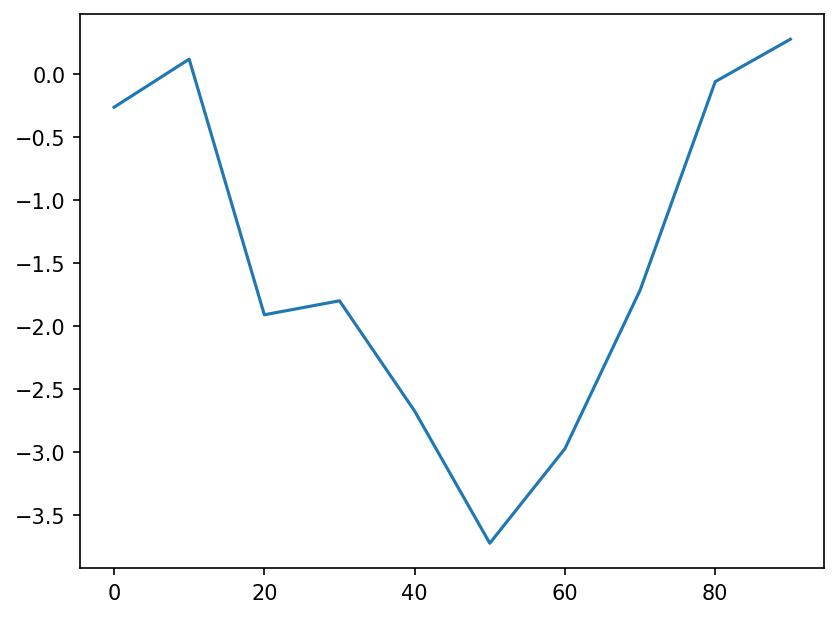

In [314]:
import matplotlib.pyplot as plt # we only need pyplot
plt.rcParams['figure.dpi'] = 150 # change resolution

s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

In [315]:
# cumsum(0) sums over index
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0), columns=['A', 'B', 'C', 'D'], index=np.arange(0, 100, 10))
df

,A,B,C,D
0,-1.401948,0.847554,-0.005771,-2.042086
10,-0.640907,2.100971,-0.380841,-2.563077
20,-1.145396,2.518005,-1.759648,-3.156554
30,-0.214362,1.821196,-2.084844,-2.749236
40,-1.784290,0.692168,-1.467634,-2.840440
50,-2.484421,-0.457763,-4.606277,-3.377520
60,-3.543820,-1.080787,-4.866213,-4.381414
70,-2.906924,-2.448903,-5.199255,-2.413419
80,-1.868304,-2.160349,-4.930502,-2.351189
90,-1.921436,-2.834003,-1.561149,-3.223046


<Axes: >

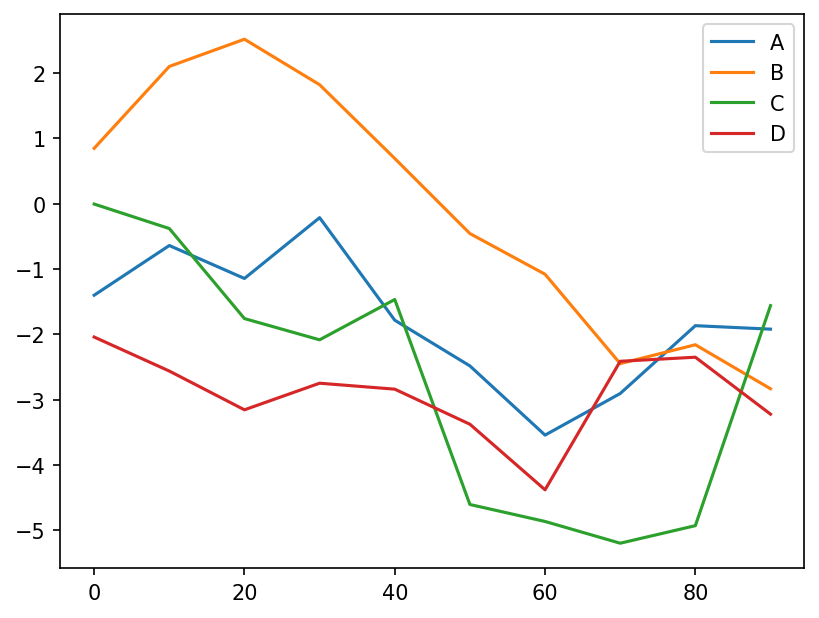

In [316]:
df.plot()

In [317]:
df = pd.DataFrame(np.random.rand(6, 4),index=['one', 'two', 'three', 'four', 'five', 'six'],\
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))


In [318]:
df

Genus,A,B,C,D
one,0.139005,0.434052,0.038859,0.449718
two,0.028166,0.720605,0.831899,0.914319
three,0.684975,0.764326,0.981352,0.020417
four,0.368877,0.739904,0.388534,0.084288
five,0.911123,0.086628,0.164418,0.374939
six,0.170384,0.235821,0.692473,0.562996


<Axes: >

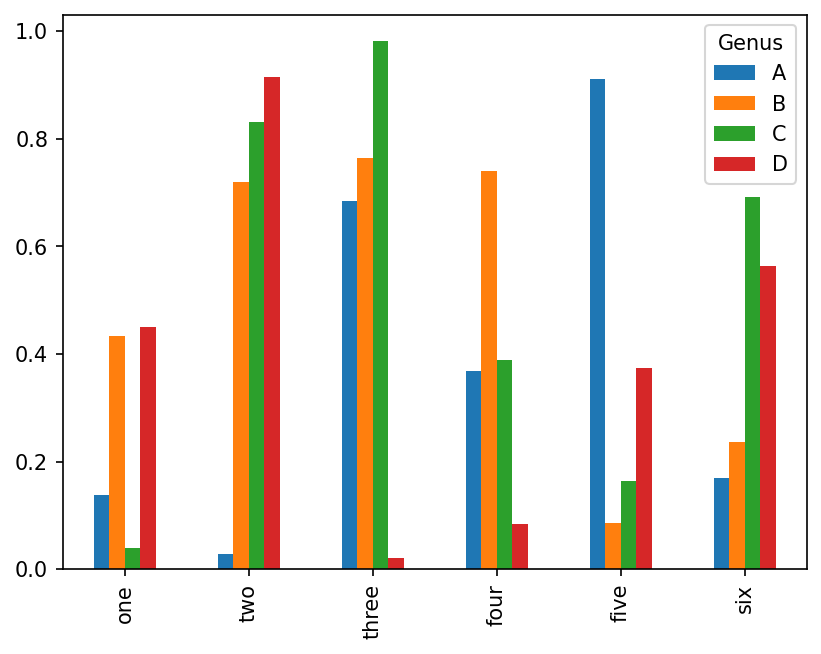

In [319]:
df.plot.bar()

<Axes: >

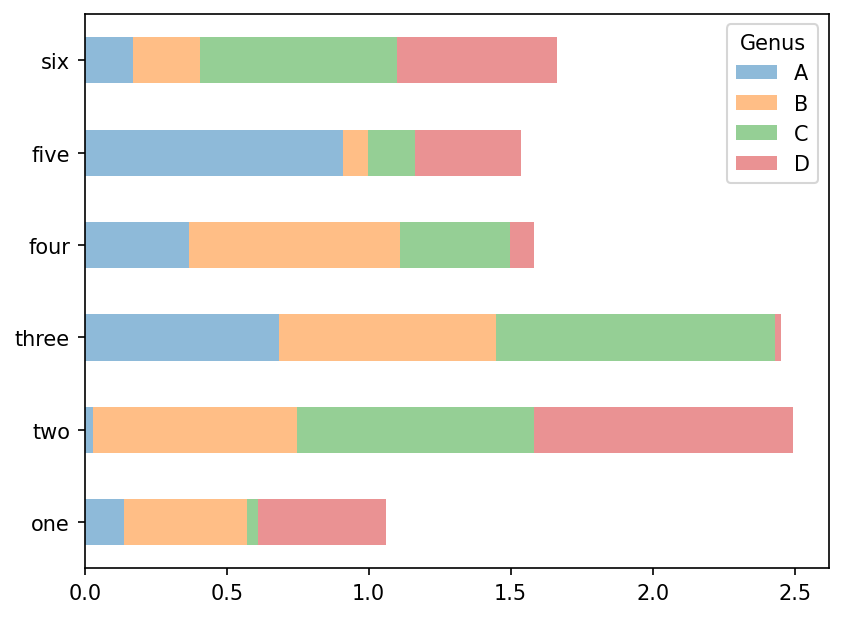

In [320]:
df.plot.barh(stacked=True, alpha=0.5)

---
# 12: Task

We will analyze US birthrate data.

In [321]:
# shell command to download the data:
!curl -O https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  258k  100  258k    0     0  1498k      0 --:--:-- --:--:-- --:--:-- 1493k


In [322]:
births = pd.read_csv('births.csv')

In [323]:
births

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548
...,...,...,...,...,...
15542,2008,10,NaN,M,183219
15543,2008,11,NaN,F,158939
15544,2008,11,NaN,M,165468
15545,2008,12,NaN,F,173215


Please answer the followings:
- Are there any null entries? If so, where are they located? How many of them? What is the reason?
- Group the data such that you can see the number of birth per month for male and female for the different years.
- What is the largest number of birth per month? Hint: use idxmax()
- What is the smallest number of birth per month? Hint: use idxmin()
- Plot the number of birth per month for both male and female.
- Create a new column finding the number of birth binned into decades
- Create a table view of male and female births as a function of decade
- Calculate the fractional difference between male and female birth over the different decades, e.g. (male birth -female birth)/(total birth). Which decade is the most lopsided by percentages?

Let's find missing entries in the data.

In [324]:
births.isnull().any()

year      False
month     False
day        True
gender    False
births    False
dtype: bool

In [325]:
births[births['day'].isnull()].head(10)

,year,month,day,gender,births
15067,1989,1,NaN,F,156749
15068,1989,1,NaN,M,164052
15069,1989,2,NaN,F,146710
15070,1989,2,NaN,M,154047
15071,1989,3,NaN,F,165889
15072,1989,3,NaN,M,174433
15073,1989,4,NaN,F,155689
15074,1989,4,NaN,M,163432
15075,1989,5,NaN,F,163800
15076,1989,5,NaN,M,172892


It appears that months with no daily information is already summed up and split into male and female category.

In [326]:
births['day'].isnull().sum()

480

There are 480 missing 'day' entries.

In [327]:
births.head(65)

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548
...,...,...,...,...,...
60,1969,1,31.0,F,4780
61,1969,1,31.0,M,4912
62,1969,1,99.0,F,26
63,1969,1,99.0,M,38


There are also days listed as 99.0, not sure what it means.

Let's create a table based on number of male/female birth per month for every year of the data.

In [328]:
groups = births.groupby(['year', 'month', 'gender']).sum()

In [329]:
groups.head()

day  births
year month gender               
1969 1     F       595.0  143730
           M       595.0  150210
     2     F       595.0  132358
           M       595.0  138428
     3     F       595.0  144084

In [330]:
groups = groups.drop(['day'], axis=1)

In [331]:
groups=groups.unstack()

In [332]:
groups.head(13)

births        
gender           F       M
year month                
1969 1      143730  150210
     2      132358  138428
     3      144084  152466
     4      137260  145378
     5      140918  148206
     6      141904  149706
     7      154614  163742
     8      155856  165178
     9      152390  160230
     10     151734  160238
     11     144964  152090
     12     153822  160700
1970 1      146754  155524

In [333]:
# Can be done easily using pivot_table!
births.pivot_table('births', index=['year', 'month'], columns='gender', aggfunc='sum')

gender           F       M
year month                
1969 1      143730  150210
     2      132358  138428
     3      144084  152466
     4      137260  145378
     5      140918  148206
...            ...     ...
2008 8      182713  191315
     9      179696  188964
     10     175314  183219
     11     158939  165468
     12     173215  181235

[480 rows x 2 columns]

Find the largest entry by month.

In [334]:
groups.loc[groups['births'].idxmax()]

births        
gender           F       M
year month                
2007 8      191495  199622
     8      191495  199622

In [335]:
groups['births', 'F'].max()

191495

In [336]:
groups.loc[groups['births', 'F'].idxmax()]

        gender
births  F         191495
        M         199622
Name: (2007, 8), dtype: int64

Find the smallest entry by month.

In [337]:
groups.loc[groups['births'].idxmin()]

births        
gender           F       M
year month                
1974 2      115870  121432
     2      115870  121432

In [338]:
groups.loc[groups['births', 'M'].idxmin()]

        gender
births  F         115870
        M         121432
Name: (1974, 2), dtype: int64

<Axes: xlabel='year,month'>

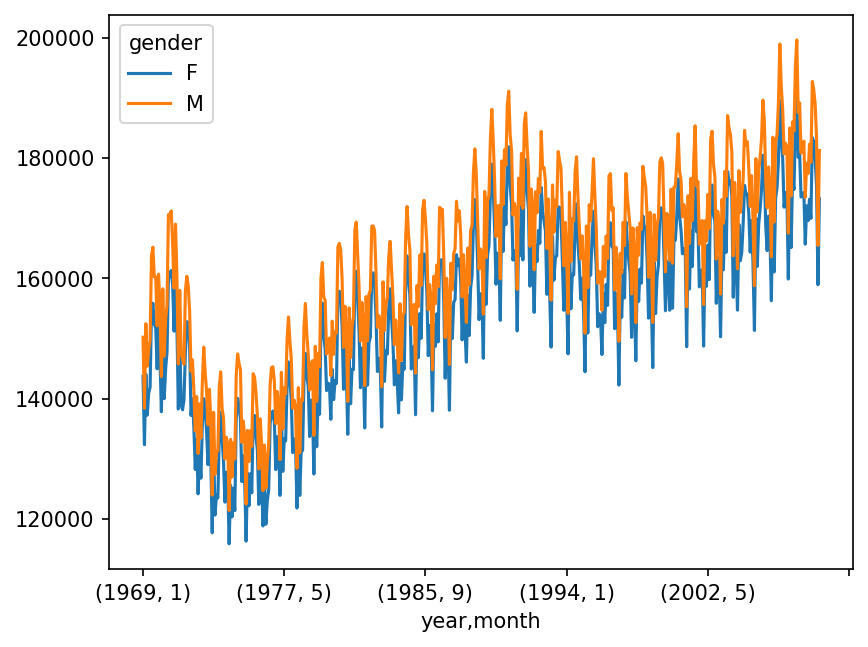

In [339]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150 # change resolution

groups['births'].plot()

In [340]:
births['decade'] = 10 * (births['year'] // 10)

In [341]:
df=births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')
df

gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


In [342]:
100*(df['M']-df['F'])/(df['M']+ df['F'])

decade
1960    2.581463
1970    2.571468
1980    2.484704
1990    2.358644
2000    2.349275
dtype: float64